# Kickstarter: EDA and Success Prediction (US, USD)

Cleaned data is scoped to **US** creators and **USD** campaigns, using both Kaggle CSVs in the same archive (`ks-projects-201612.csv` and `ks-projects-201801.csv`). After filters, `data/cleaned/snapshot_comparison.json` summarizes rows and success rate by export; the modeling CSV keeps one row per project (later snapshot wins when an id appears in both).

Load cleaned data, run EDA, then fit a baseline logistic regression and a Random Forest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PATH = Path("../data/cleaned")
REPORT = Path("../report")
REPORT.mkdir(parents=True, exist_ok=True)

# Load cleaned data (use CSV; or query SQLite if preferred)
df = pd.read_csv(PATH / "kickstarter_cleaned.csv")
df["launched"] = pd.to_datetime(df["launched"], errors="coerce")
df["deadline"] = pd.to_datetime(df["deadline"], errors="coerce")
print(df.shape)
df.head()

(261360, 16)


,id,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd_pledged,snapshot_year,usd_goal_real,usd_pledged_real
0,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,NaT,30000.0,2017-09-02 04:43:57,2421.0,failed,15.0,US,100.0,2018,30000.0,2421.0
1,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,NaT,45000.0,2013-01-12 00:20:50,220.0,failed,3.0,US,220.0,2018,45000.0,220.0
2,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,NaT,5000.0,2012-03-17 03:24:11,1.0,failed,1.0,US,1.0,2018,5000.0,1.0
3,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,NaT,50000.0,2016-02-26 13:38:27,52375.0,successful,224.0,US,52375.0,2018,50000.0,52375.0
4,1000023410,Support Solar Roasted Coffee & Green Energy! ...,Food,Food,USD,NaT,1000.0,2014-12-01 18:30:44,1205.0,successful,16.0,US,1205.0,2018,1000.0,1205.0


## Missingness and summary stats

In [2]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 261360 entries, 0 to 261359
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                261360 non-null  int64         
 1   name              261358 non-null  str           
 2   category          261360 non-null  str           
 3   main_category     261360 non-null  str           
 4   currency          261360 non-null  str           
 5   deadline          0 non-null       datetime64[s] 
 6   goal              261360 non-null  float64       
 7   launched          261360 non-null  datetime64[us]
 8   pledged           261360 non-null  float64       
 9   state             261360 non-null  str           
 10  backers           261360 non-null  float64       
 11  country           261360 non-null  str           
 12  usd_pledged       261360 non-null  float64       
 13  snapshot_year     261360 non-null  int64         
 14  usd_goal_real  

,id,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd_pledged,snapshot_year,usd_goal_real,usd_pledged_real
count,2.613600e+05,261358,261360,261360,261360,0,2.613600e+05,261360,2.613600e+05,261360,261360.000000,261360,2.613600e+05,261360.0,2.613600e+05,2.613600e+05
unique,NaN,259975,159,15,1,NaN,NaN,NaN,NaN,2,NaN,1,NaN,NaN,NaN,NaN
top,NaN,New EP/Music Development,Product Design,Film & Video,USD,NaN,NaN,NaN,NaN,failed,NaN,US,NaN,NaN,NaN,NaN
freq,NaN,13,13732,46933,261360,NaN,NaN,NaN,NaN,152061,NaN,261360,NaN,NaN,NaN,NaN
mean,1.075172e+09,NaN,NaN,NaN,NaN,NaT,3.934953e+04,2014-05-14 04:56:22.655452,1.048196e+04,NaN,122.744739,NaN,8.335880e+03,2018.0,3.934953e+04,1.048196e+04
min,5.971000e+03,NaN,NaN,NaN,NaN,NaT,1.000000e-02,2009-04-21 21:02:48,0.000000e+00,NaN,0.000000,NaN,0.000000e+00,2018.0,1.000000e-02,0.000000e+00
25%,5.383048e+08,NaN,NaN,NaN,NaN,NaT,2.000000e+03,2012-10-02 23:51:32.750000,5.600000e+01,NaN,2.000000,NaN,3.500000e+01,2018.0,2.000000e+03,5.600000e+01
50%,1.076273e+09,NaN,NaN,NaN,NaN,NaT,5.000000e+03,2014-07-18 01:02:41.500000,9.100000e+02,NaN,17.000000,NaN,6.260000e+02,2018.0,5.000000e+03,9.100000e+02
75%,1.611158e+09,NaN,NaN,NaN,NaN,NaT,1.500000e+04,2015-11-10 03:55:39.750000,5.020000e+03,NaN,66.000000,NaN,3.861000e+03,2018.0,1.500000e+04,5.020000e+03
max,2.147476e+09,NaN,NaN,NaN,NaN,NaT,1.000000e+08,2017-12-28 01:48:58,2.033899e+07,NaN,219382.000000,NaN,2.033899e+07,2018.0,1.000000e+08,2.033899e+07


In [3]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

deadline    261360
name             2
dtype: int64

## Distributions: goal, backers, state

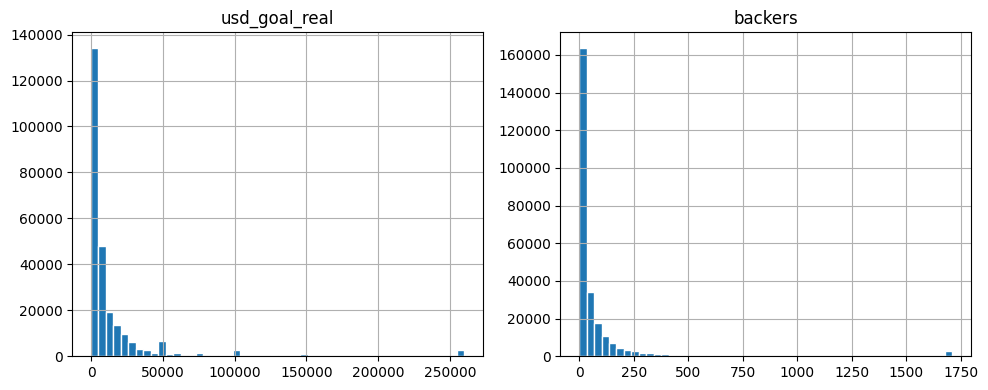

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["usd_goal_real", "backers"]):
    if col in df.columns:
        df[col].clip(upper=df[col].quantile(0.99)).hist(ax=ax, bins=50, edgecolor="white")
        ax.set_title(col)
plt.tight_layout()
plt.savefig(REPORT / "distributions_goal_backers.png", dpi=150, bbox_inches="tight")
plt.show()

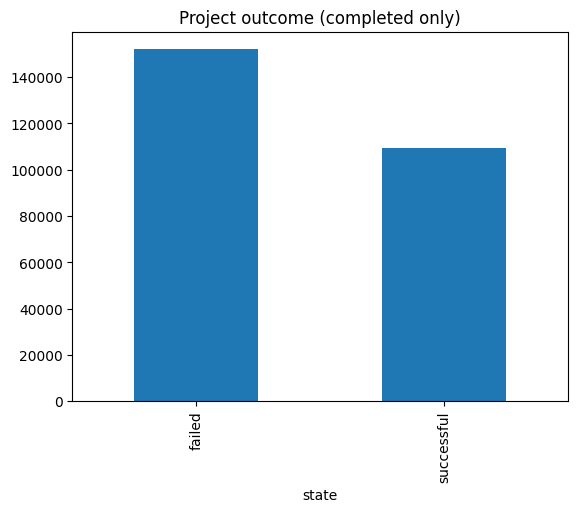

In [5]:
if "state" in df.columns:
    df["state"].value_counts().plot(kind="bar")
    plt.title("Project outcome (completed only)")
    plt.savefig(REPORT / "distribution_state.png", dpi=150, bbox_inches="tight")
    plt.show()

## Relationships: success rate by category, goal vs pledged

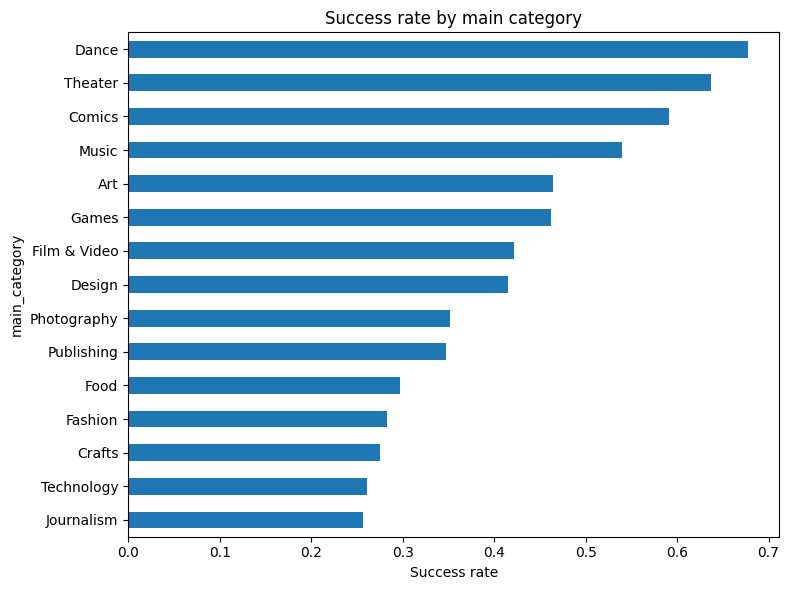

In [6]:
if "main_category" in df.columns and "state" in df.columns:
    rate = df.groupby("main_category")["state"].apply(lambda x: (x == "successful").mean()).sort_values(ascending=True)
    rate.plot(kind="barh", figsize=(8, 6))
    plt.title("Success rate by main category")
    plt.xlabel("Success rate")
    plt.tight_layout()
    plt.savefig(REPORT / "success_rate_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()

In [7]:
# Insight: categories with higher success rate can inform the prediction task (feature importance)
print("Sample insight: Success rate varies strongly by main_category in EDA; in the model, backers and goal size are the top predictors.")

Sample insight: Success rate varies strongly by main_category in EDA; in the model, backers and goal size are the top predictors.


## Prediction: baseline and improved model

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

df_model = df.copy()
df_model["target"] = (df_model["state"] == "successful").astype(int)

feat_numeric = ["usd_goal_real", "backers"]
# Country is constant (US) after ETL scope; categorical signal is main_category
feat_cat = ["main_category"]
use = [c for c in feat_numeric + feat_cat if c in df_model.columns]
df_model = df_model.dropna(subset=use + ["target"])

In [9]:
X = df_model[use].copy()
for c in feat_cat:
    if c in X.columns:
        X[c] = LabelEncoder().fit_transform(X[c].astype(str))
y = df_model["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [10]:
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_s, y_train)
pred_b = baseline.predict(X_test_s)
print("Baseline (Logistic Regression):")
print("  Accuracy:", accuracy_score(y_test, pred_b))
print("  Precision:", precision_score(y_test, pred_b, zero_division=0))
print("  Recall:", recall_score(y_test, pred_b, zero_division=0))
print("  F1:", f1_score(y_test, pred_b, zero_division=0))
print("  ROC-AUC:", roc_auc_score(y_test, baseline.predict_proba(X_test_s)[:, 1]))

Baseline (Logistic Regression):
  Accuracy: 0.8656259565350475
  Precision: 0.9244468924997705
  Recall: 0.7384322064970301
  F1: 0.8210354667753771
  ROC-AUC: 0.9631401130946575


In [11]:
improved = RandomForestClassifier(n_estimators=100, random_state=42)
improved.fit(X_train, y_train)  # RF can handle raw labels for cat features in this setup
X_test_rf = X_test.copy()
pred_i = improved.predict(X_test_rf)
print("Improved (Random Forest):")
print("  Accuracy:", accuracy_score(y_test, pred_i))
print("  Precision:", precision_score(y_test, pred_i, zero_division=0))
print("  Recall:", recall_score(y_test, pred_i, zero_division=0))
print("  F1:", f1_score(y_test, pred_i, zero_division=0))
print("  ROC-AUC:", roc_auc_score(y_test, improved.predict_proba(X_test_rf)[:, 1]))

Improved (Random Forest):
  Accuracy: 0.9217936945209673
  Precision: 0.9028646212011051
  Recall: 0.9106108381608858
  F1: 0.9067211857909533


  ROC-AUC: 0.9727085882194374


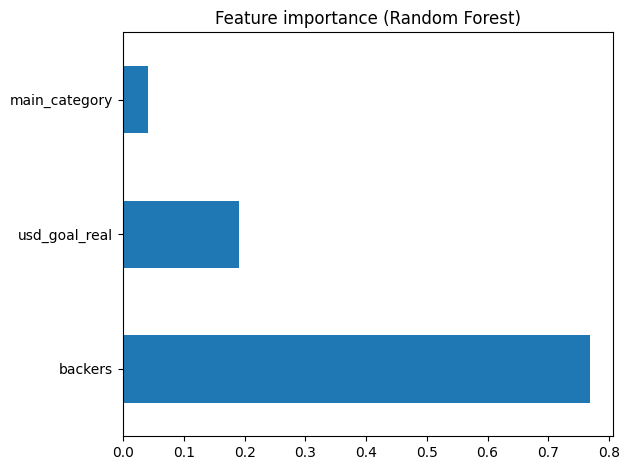

In [12]:
imp = pd.Series(improved.feature_importances_, index=use).sort_values(ascending=False)
imp.plot(kind="barh")
plt.title("Feature importance (Random Forest)")
plt.tight_layout()
plt.savefig(REPORT / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()